# Problem 2.46: 2D Sobel Filtering and Edge Detection

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
In this problem use the Lena image available in the book toolbox.
* **(a)** Load the Lena image in MATLAB/Python and display using `imshow`.
* **(b)** Consider the $3 \times 3$ impulse response $h[m, n]$ (known as a Sobel filter) given below:
  $$
  h_v[m, n] = \begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix}
  $$
  in which the $[0, 0]$ term is in the center. Filter the Lena image using this impulse response and display the resulting image. Comment on the result.
* **(c)** Repeat part (b) using the impulse response:
  $$
  h_h[m, n] = \begin{bmatrix} 1 & 2 & 1 \\ 0 & 0 & 0 \\ -1 & -2 & -1 \end{bmatrix}
  $$
  and comment on the result.

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.signal import convolve2d


## (a) Load and Display Original Image

Image size: 512 x 512


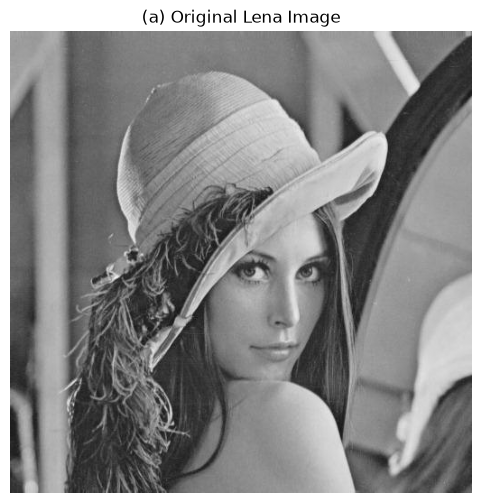

In [4]:
image_path = Path('lena.jpg')
if not image_path.exists():
    import urllib.request
    url = 'https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg'
    urllib.request.urlretrieve(url, image_path)

img = Image.open(image_path).convert('L')
x = np.array(img, dtype=np.float64)

print(f"Image size: {x.shape[0]} x {x.shape[1]}")
plt.figure(figsize=(6, 6))
plt.imshow(x, cmap='gray', vmin=0, vmax=255)
plt.title('(a) Original Lena Image')
plt.axis('off')
plt.show()


## (b) Vertical Edge Detection (Horizontal Gradient Sobel Filter)
The impulse response:
$$
h_v[m, n] = \begin{bmatrix} 1 & 0 & -1 \\ 2 & 0 & -2 \\ 1 & 0 & -1 \end{bmatrix}
$$
computes the difference between columns (horizontal derivative) while applying smoothing across rows ($[1, 2, 1]^T$). It responds strongly to intensity changes along the horizontal direction, highlighting **vertical edges**.

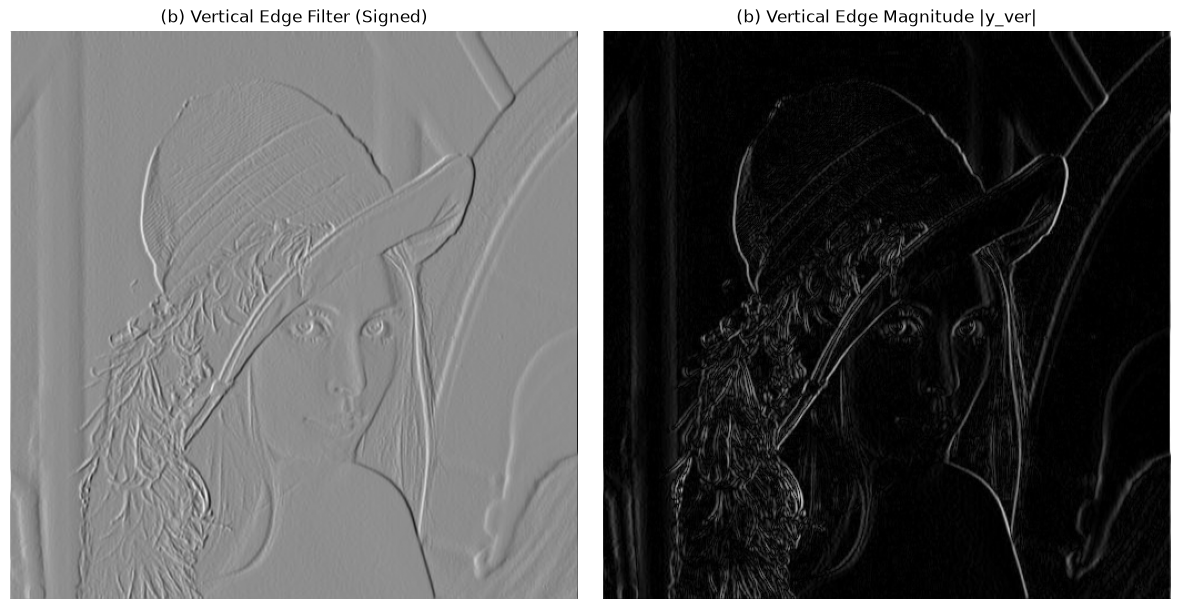

In [6]:
hv = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float64)

# 2D convolution with zero boundary conditions
y_ver = convolve2d(x, hv, mode='same', boundary='fill', fillvalue=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(y_ver, cmap='gray')
axes[0].set_title('(b) Vertical Edge Filter (Signed)')
axes[0].axis('off')

axes[1].imshow(np.abs(y_ver), cmap='gray')
axes[1].set_title('(b) Vertical Edge Magnitude |y_ver|')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## (c) Horizontal Edge Detection (Vertical Gradient Sobel Filter)
The impulse response:
$$
h_h[m, n] = \begin{bmatrix} 1 & 2 & 1 \\ 0 & 0 & 0 \\ -1 & -2 & -1 \end{bmatrix}
$$
computes the difference between rows (vertical derivative) while smoothing across columns. It responds strongly to intensity changes along the vertical direction, highlighting **horizontal edges**.

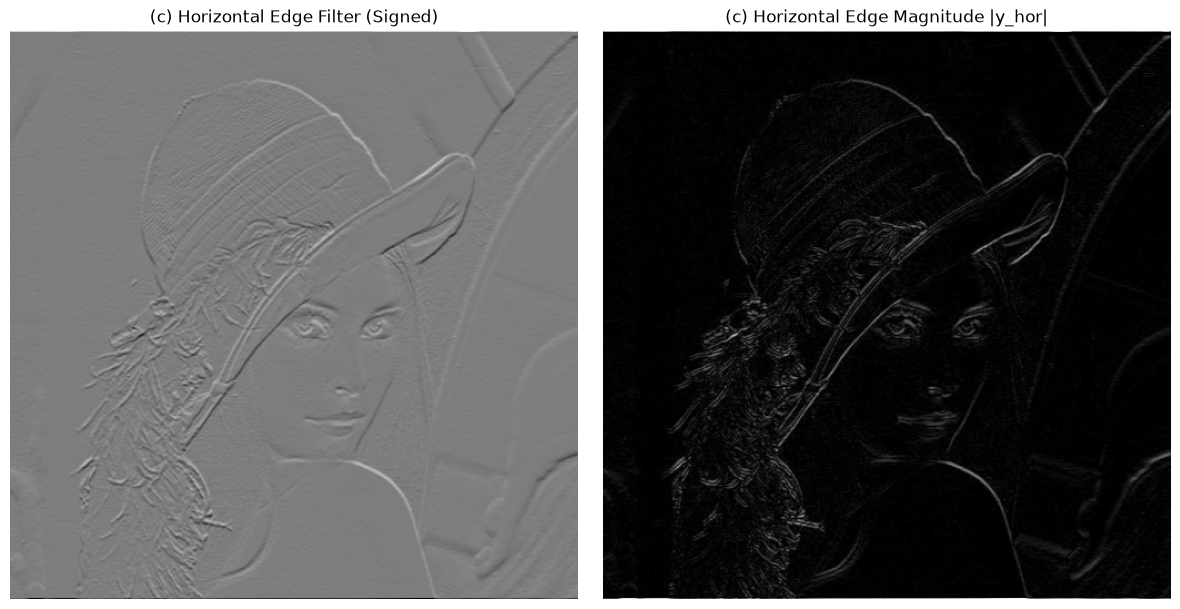

In [8]:
hh = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float64)

y_hor = convolve2d(x, hh, mode='same', boundary='fill', fillvalue=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(y_hor, cmap='gray')
axes[0].set_title('(c) Horizontal Edge Filter (Signed)')
axes[0].axis('off')

axes[1].imshow(np.abs(y_hor), cmap='gray')
axes[1].set_title('(c) Horizontal Edge Magnitude |y_hor|')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Combined Sobel Gradient Magnitude
Combining both directional filters yields the total edge magnitude:
$$
G[m, n] = \sqrt{y_{\text{ver}}[m, n]^2 + y_{\text{hor}}[m, n]^2}
$$

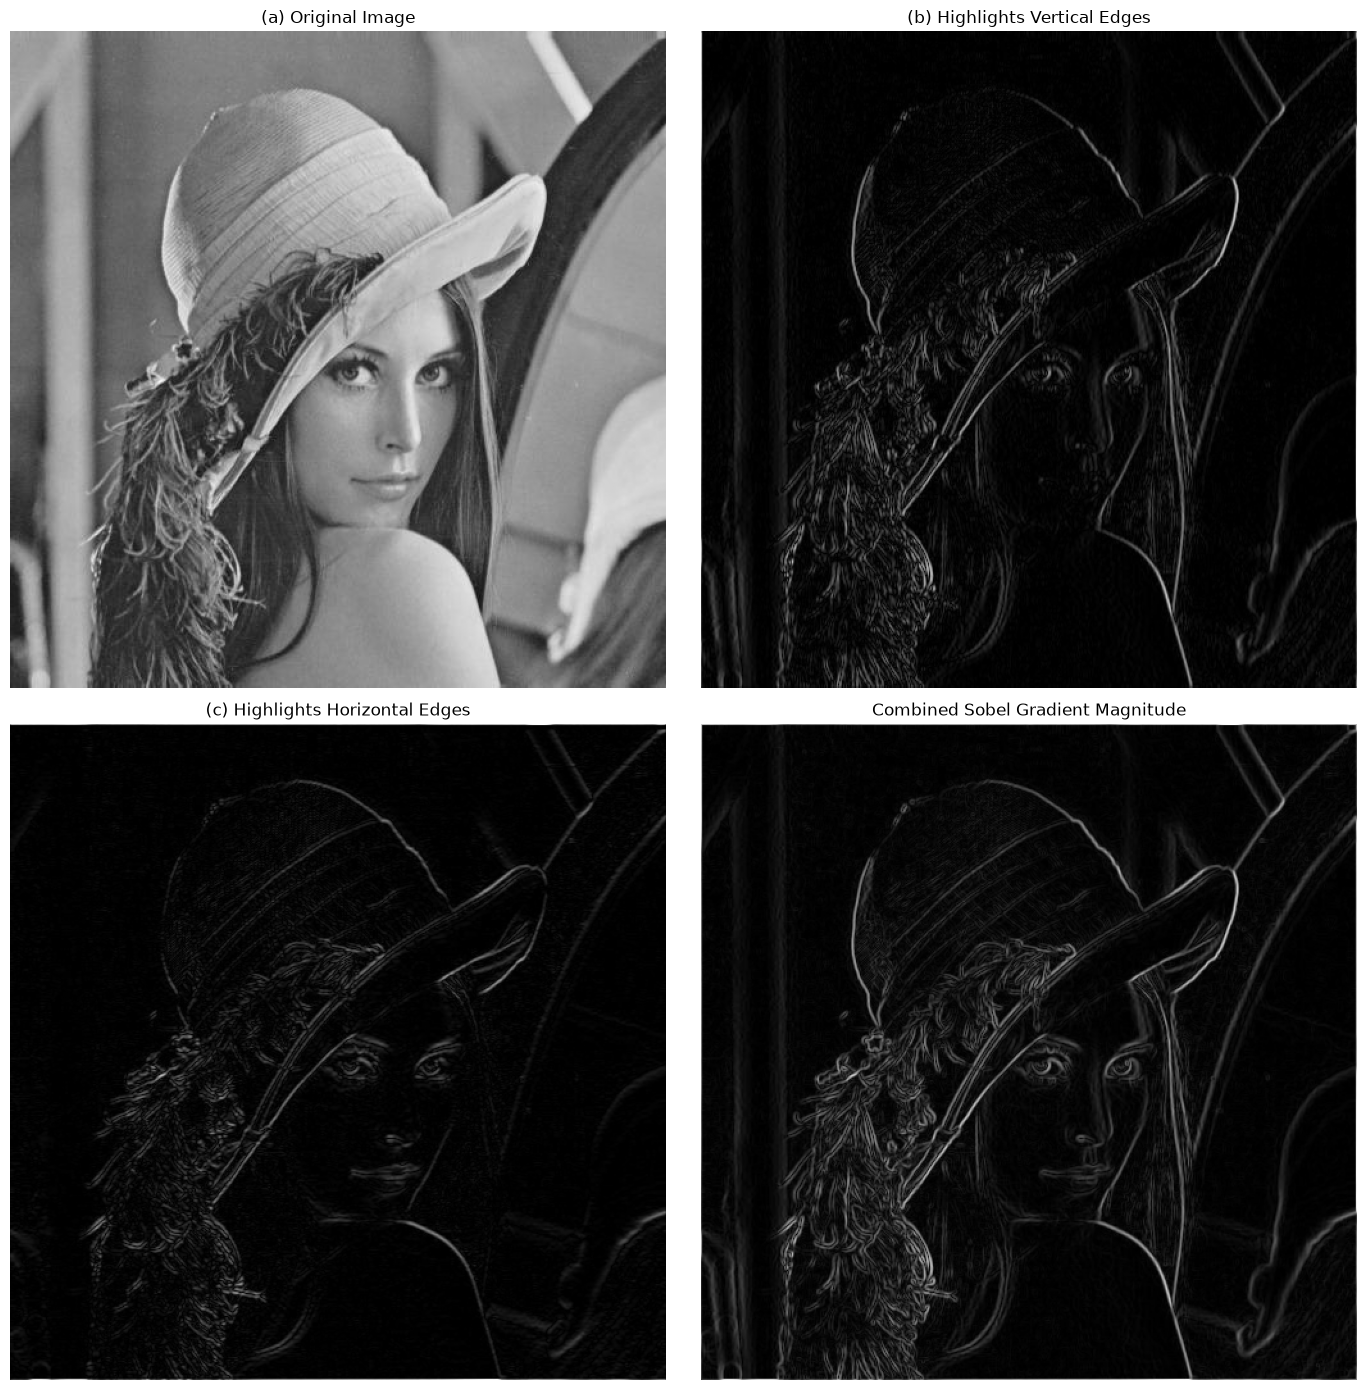

In [10]:
G = np.sqrt(y_ver**2 + y_hor**2)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0, 0].imshow(x, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('(a) Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(y_ver), cmap='gray')
axes[0, 1].set_title('(b) Highlights Vertical Edges')
axes[0, 1].axis('off')

axes[1, 0].imshow(np.abs(y_hor), cmap='gray')
axes[1, 0].set_title('(c) Highlights Horizontal Edges')
axes[1, 0].axis('off')

axes[1, 1].imshow(G, cmap='gray')
axes[1, 1].set_title('Combined Sobel Gradient Magnitude')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
